# Plant Disease Detection: Computer Vision Pipeline

This notebook demonstrates a complete computer vision pipeline for plant disease detection, including preprocessing, segmentation, and feature extraction. The goal is to extract meaningful features from leaf images that can later be used for classification.

## 1. Dataset

We will use a small sample of plant leaf images. You can replace the image paths with your own dataset.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage import morphology
import os

import os

dataset_root = '../data/raw/PlantVillage/tomato'
image_limit_per_class = 200

image_files = []
labels = []

for class_name in os.listdir(dataset_root):

    class_path = os.path.join(dataset_root, class_name)

    if not os.path.isdir(class_path):
        continue

    files = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    # take only n images per class
    #files = files[:image_limit_per_class]

    for f in files:
        image_files.append(f)
        labels.append(class_name)

print("Total images:", len(image_files))
print("Classes found:", set(labels))

Total images: 16011
Classes found: {'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus'}


## 2. Preprocessing

We resize images to 256x256, apply Gaussian blur for denoising, and convert to grayscale and HSV. This step helps standardize the data and reduce noise.

In [24]:
def preprocess_image(img, size=(256, 256)):
    img_resized = cv2.resize(img, size)
    img_blur = cv2.GaussianBlur(img_resized, (5, 5), 0)
    img_gray = cv2.cvtColor(img_blur, cv2.COLOR_BGR2GRAY)
    img_hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)
    return img_resized, img_blur, img_gray, img_hsv


# Visualize preprocessing
'''
for img_path in image_files:
    img = cv2.imread(img_path)
    img_resized, img_blur, img_gray, img_hsv = preprocess_image(img)
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')
    axs[1].imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB)); axs[1].set_title('Denoised')
    axs[2].imshow(img_gray, cmap='gray'); axs[2].set_title('Grayscale')
    axs[3].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)); axs[3].set_title('HSV')
    for ax in axs: ax.axis('off')
    plt.suptitle(f'Preprocessing: {os.path.basename(img_path)}')
    plt.show()
    '''

"\nfor img_path in image_files:\n    img = cv2.imread(img_path)\n    img_resized, img_blur, img_gray, img_hsv = preprocess_image(img)\n    fig, axs = plt.subplots(1, 4, figsize=(16, 4))\n    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axs[0].set_title('Original')\n    axs[1].imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB)); axs[1].set_title('Denoised')\n    axs[2].imshow(img_gray, cmap='gray'); axs[2].set_title('Grayscale')\n    axs[3].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)); axs[3].set_title('HSV')\n    for ax in axs: ax.axis('off')\n    plt.suptitle(f'Preprocessing: {os.path.basename(img_path)}')\n    plt.show()\n    "

## 3. Segmentation

We segment the leaf using two methods: Otsu thresholding and HSV color segmentation. Optionally, KMeans clustering can be used. Morphological operations are applied to clean the masks.

In [25]:

def normalize_lighting(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
def normalize_illumination(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
def segment_hsv_robust(img_bgr):
    img_bgr = normalize_lighting(img_bgr)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # tighter and more robust green range
    lower = np.array([30, 40, 40])
    upper = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    return mask
def clean_mask(mask):
    kernel_small = np.ones((3,3), np.uint8)
    kernel_big = np.ones((7,7), np.uint8)

    # remove noise first
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_small)

    # fill holes
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)

    # keep only largest region (VERY important)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask_clean = np.zeros_like(mask)
        mask_clean[labels == largest] = 255
        return mask_clean

    return mask
def segment_leaf(img_bgr):

    # 1. fix lighting first
    img_bgr = normalize_illumination(img_bgr)

    # 2. HSV segmentation
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    lower = np.array([30, 30, 30])
    upper = np.array([95, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # 3. cleanup
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask


for img_path in image_files:

    img = cv2.imread(img_path)

    # safety check
    if img is None:
        print(f"Failed to load: {img_path}")
        continue

    # --- segmentation (your upgraded pipeline) ---
    result_mask = segment_leaf(img)

    # --- convert for display ---
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- visualization ---
    '''overlay = img_rgb.copy()
    overlay[result_mask == 0] = [0, 0, 0]

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(result_mask, cmap='gray')
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Leaf Extracted")
    plt.axis("off")

    plt.show()
    # --- Segmentation ---'''
    ''' mask_otsu = segment_threshold(gray)
    mask_hsv = segment_hsv(hsv)

    # --- Contours / texture ---
    canny, sobel = edge_detection(gray)

    # --- Clustering ---
    kmeans_img, labels = segment_kmeans(img_rgb, k=20)

    # --- Visualisation ---
    fig, axs = plt.subplots(1, 6, figsize=(20, 4))
    final_mask = combine_masks(mask_hsv, mask_otsu)
    axs[0].imshow(img_rgb); axs[0].set_title("Original")
    axs[1].imshow(mask_otsu, cmap='gray'); axs[1].set_title("Otsu (Feuille)")
    axs[2].imshow(mask_hsv, cmap='gray'); axs[2].set_title("HSV Segmentation")
    axs[3].imshow(canny, cmap='gray'); axs[3].set_title("Canny (Contours)")
    axs[4].imshow(kmeans_img); axs[4].set_title("KMeans")
    axs[5].imshow(final_mask, cmap='gray'); axs[5].set_title("Final Mask")

    for ax in axs:
        ax.axis("off")
    '''
   

### Segmentation Method Comparison

- **Otsu thresholding**: Simple, works well for high-contrast images but may include background.
- **HSV segmentation**: Targets green hues, robust to lighting but may miss diseased/brown areas.
- **Combined mask**: Merges strengths of both and cleans up noise.

You can experiment with KMeans or other methods for further improvement.

## 4. Feature Extraction

We extract color, texture, and shape features from the segmented leaf. These features are useful for classifying plant diseases.

In [26]:
import os
import cv2
import numpy as np
import pandas as pd

# =========================
# 1. FEATURE FUNCTIONS
# =========================

def extract_color_features(img, mask):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0][mask > 0]
    s = hsv[:, :, 1][mask > 0]
    v = hsv[:, :, 2][mask > 0]

    return {
        "h_mean": np.mean(h),
        "s_mean": np.mean(s),
        "v_mean": np.mean(v),
        "h_std": np.std(h),
        "s_std": np.std(s),
        "v_std": np.std(v),
    }


from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(gray_img, mask):

    gray = gray_img.copy()
    gray[mask == 0] = 0

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return {
        "contrast": graycoprops(glcm, 'contrast')[0, 0],
        "energy": graycoprops(glcm, 'energy')[0, 0],
        "homogeneity": graycoprops(glcm, 'homogeneity')[0, 0]
    }


def extract_shape_features(mask):

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return {"area": 0, "perimeter": 0, "circularity": 0}

    c = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)

    circularity = 0
    if perimeter > 0:
        circularity = 4 * np.pi * area / (perimeter ** 2)

    return {
        "area": area,
        "perimeter": perimeter,
        "circularity": circularity
    }


# =========================
# 2. BUILD DATASET
# =========================

data = []

for img_path in image_files:

    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # segmentation
    mask = segment_leaf(img)

    # extract features
    color_feats = extract_color_features(img, mask)
    texture_feats = extract_glcm_features(gray, mask)
    shape_feats = extract_shape_features(mask)

    # label = folder name (IMPORTANT)
    label = os.path.basename(os.path.dirname(img_path))

    # merge all features
    row = {
        "image": img_path,
        "label": label,
        **color_feats,
        **texture_feats,
        **shape_feats
    }

    data.append(row)


# =========================
# 3. SAVE CSV
# =========================

df = pd.DataFrame(data)

output_path = "../results/combined_run/features/features.csv"
df.to_csv(output_path, index=False)

print(f"Saved features to {output_path}")
print(df.head())

c:\Users\louay\OneDrive\Desktop\computer vision\venv\lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\louay\OneDrive\Desktop\computer vision\venv\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\louay\OneDrive\Desktop\computer vision\venv\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\louay\OneDrive\Desktop\computer vision\venv\lib\site-packages\numpy\_core\_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\louay\OneDrive\Desktop\computer vision\venv\lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Saved features to ../results/combined_run/features/features.csv
                                               image                  label  \
0  ../data/raw/PlantVillage/tomato\Tomato_Bacteri...  Tomato_Bacterial_spot   
1  ../data/raw/PlantVillage/tomato\Tomato_Bacteri...  Tomato_Bacterial_spot   
2  ../data/raw/PlantVillage/tomato\Tomato_Bacteri...  Tomato_Bacterial_spot   
3  ../data/raw/PlantVillage/tomato\Tomato_Bacteri...  Tomato_Bacterial_spot   
4  ../data/raw/PlantVillage/tomato\Tomato_Bacteri...  Tomato_Bacterial_spot   

      h_mean      s_mean      v_mean      h_std      s_std      v_std  \
0  71.628404   87.917245   67.256930   7.686300  20.644801  14.342843   
1  57.298869  117.250409   97.999733   7.768356  31.905115  20.729127   
2  40.909549  121.713244  125.711654   4.319640  30.796036  24.407721   
3  57.222080   85.720396  110.551085   9.544746  28.706217  23.035829   
4  68.435225   92.073462   71.687666  10.523294  27.823891  18.512898   

     contrast    energ

## 5. Conclusion

- **Best segmentation**: The combined mask generally provides the cleanest leaf segmentation by leveraging both Otsu and HSV methods.
- **Feature usage**: Extracted color, texture, and shape features can be used as input to machine learning classifiers (e.g., SVM, Random Forest) to distinguish between healthy and diseased leaves.

This pipeline provides a solid foundation for plant disease detection using computer vision.


RandomForest
Accuracy: 0.8022492970946579
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.87      0.84      0.86       426
                        Tomato_Early_blight       0.66      0.44      0.53       200
                         Tomato_Late_blight       0.73      0.71      0.72       380
                           Tomato_Leaf_Mold       0.73      0.62      0.67       190
                  Tomato_Septoria_leaf_spot       0.78      0.81      0.79       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.72      0.84      0.77       335
                        Tomato__Target_Spot       0.74      0.76      0.75       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.87      0.93      0.90       642
                Tomato__Tomato_mosaic_virus       0.89      0.79      0.84        75
                             Tomato_healthy       0.91      0.93      0.92       318

                    

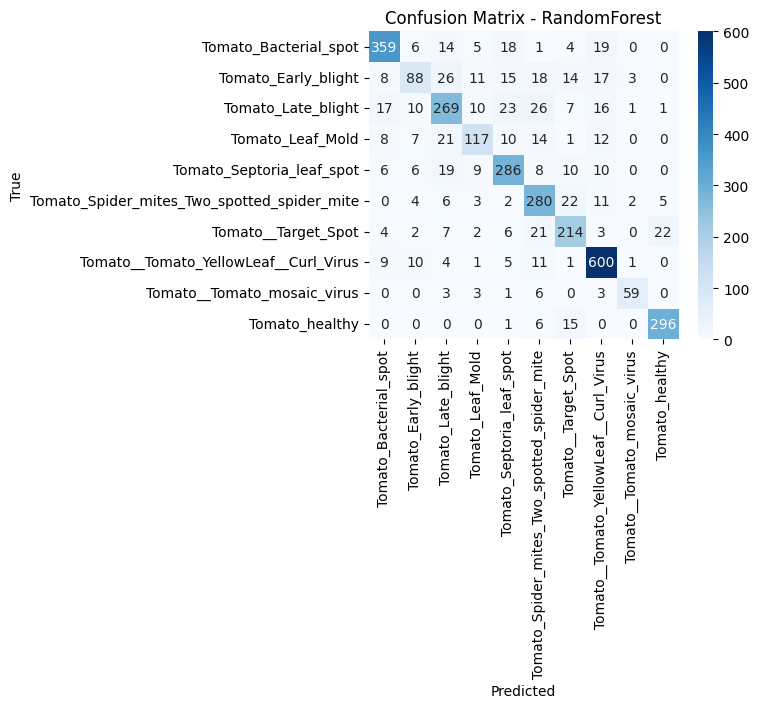


SVM
Accuracy: 0.8128709778194314
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.85      0.85      0.85       426
                        Tomato_Early_blight       0.69      0.46      0.55       200
                         Tomato_Late_blight       0.69      0.71      0.70       380
                           Tomato_Leaf_Mold       0.74      0.71      0.72       190
                  Tomato_Septoria_leaf_spot       0.80      0.77      0.79       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.75      0.82      0.79       335
                        Tomato__Target_Spot       0.74      0.80      0.77       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.91      0.95      0.93       642
                Tomato__Tomato_mosaic_virus       0.85      0.88      0.86        75
                             Tomato_healthy       0.94      0.92      0.93       318

                             

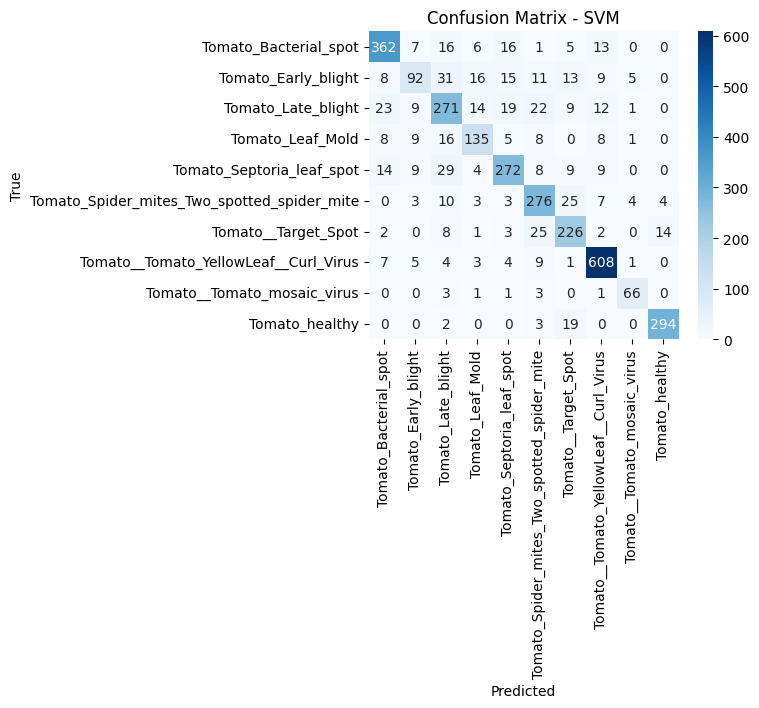


KNN
Accuracy: 0.7800687285223368
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.81      0.87      0.84       426
                        Tomato_Early_blight       0.63      0.46      0.53       200
                         Tomato_Late_blight       0.72      0.63      0.68       380
                           Tomato_Leaf_Mold       0.69      0.72      0.70       190
                  Tomato_Septoria_leaf_spot       0.77      0.74      0.75       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.68      0.78      0.73       335
                        Tomato__Target_Spot       0.71      0.70      0.71       281
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.87      0.93      0.90       642
                Tomato__Tomato_mosaic_virus       0.82      0.83      0.82        75
                             Tomato_healthy       0.91      0.88      0.90       318

                             

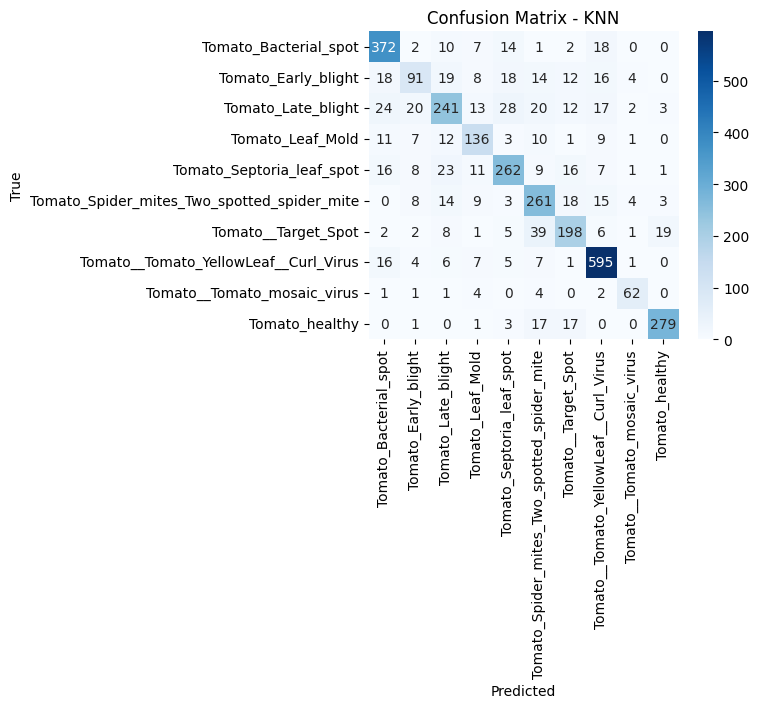


Final Model Comparison:
          Model  Accuracy
1           SVM  0.812871
0  RandomForest  0.802249
2           KNN  0.780069

Models saved to: ..\results\combined_run\models


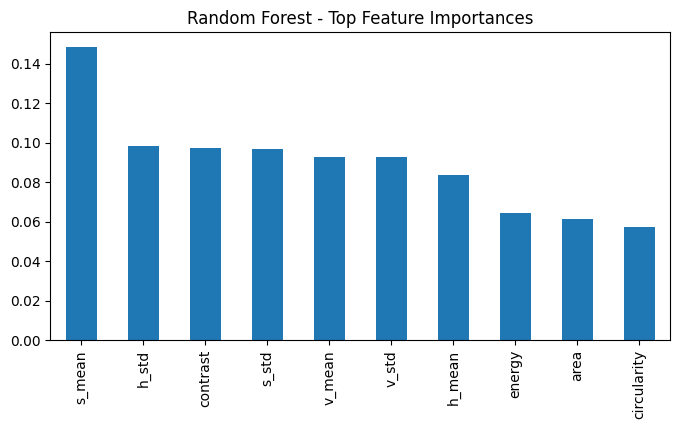

In [27]:
# Classification: train RF / SVM / KNN, evaluate, save models

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# =========================
# 1. LOAD DATASET
# =========================
csv_path = Path(r"C:\Users\louay\OneDrive\Desktop\computer vision\results\combined_run\features\features.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Features CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df = df.dropna()

if df.empty:
    raise ValueError('No feature rows after dropping NaNs')

# feature columns
X_cols = [c for c in df.columns if c not in ('image', 'label')]

if len(X_cols) == 0:
    raise ValueError('No feature columns found in CSV')

X = df[X_cols].values
y = df['label'].values


# =========================
# 2. LABEL ENCODING
# =========================
le = LabelEncoder()
y_enc = le.fit_transform(y)

if len(np.unique(y_enc)) < 2:
    raise ValueError(f'Need at least 2 classes. Found: {np.unique(y)}')


# =========================
# 3. TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    stratify=y_enc,
    random_state=42
)


# =========================
# 4. MODELS
# =========================
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', probability=True, random_state=42)
    ),

    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    )
}


trained_models = {}
results = []


# =========================
# 5. TRAIN + EVALUATE
# =========================
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print("\n" + "="*40)
    print(f"{name}")
    print("="*40)

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    trained_models[name] = model


# =========================
# 6. SUMMARY TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\nFinal Model Comparison:")
print(results_df.sort_values(by="Accuracy", ascending=False))


# =========================
# 7. SAVE MODELS
# =========================
models_dir = globals().get('models_dir', Path('../results/combined_run/models'))
models_dir = Path(models_dir)
models_dir.mkdir(parents=True, exist_ok=True)

for name, model in trained_models.items():
    joblib.dump(model, models_dir / f'{name}.joblib')

joblib.dump(le, models_dir / 'label_encoder.joblib')

print("\nModels saved to:", models_dir)


# =========================
# 8. FEATURE IMPORTANCE (RF only)
# =========================
rf = trained_models.get("RandomForest")

if rf is not None and hasattr(rf, "feature_importances_"):
    fi = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=False)

    plt.figure(figsize=(8,4))
    fi.head(10).plot.bar()
    plt.title("Random Forest - Top Feature Importances")
    plt.show()